# Assignment-8: Logistic Regression

**Objective:** Implement Logistic Regression, classify a dataset, visualize decision boundary, and evaluate performance.

---

## Q1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
print('Libraries imported')

Libraries imported


## Q2: Load Dataset (Iris — Binary Subset)

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.rename(columns={'target':'class'}, inplace=True)
df['class'] = df['class'].apply(lambda i: iris.target_names[i])

# Use only 2 classes for logistic regression visualization
df = df[df['class'].isin(['setosa', 'versicolor'])]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Q3: Dataset Information

In [3]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nClasses:', df['class'].unique())
df.describe()

Shape: (100, 5)

Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'class']

Classes: [np.str_('setosa') np.str_('versicolor')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,100.000000,100.000000,100.000000,100.000000
mean,5.471000,3.099000,2.861000,0.786000
std,0.641698,0.478739,1.449549,0.565153
min,4.300000,2.000000,1.000000,0.100000
25%,5.000000,2.800000,1.500000,0.200000
50%,5.400000,3.050000,2.450000,0.800000
75%,5.900000,3.400000,4.325000,1.300000
max,7.000000,4.400000,5.100000,1.800000


## Q4: Select Features and Target (Two Features)

In [4]:
X = df[['petal length (cm)', 'petal width (cm)']]
y = df['class']
X.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


## Q5: Split into Train and Test (70:30)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (70, 2)
Testing size: (30, 2)


## Q6: Build Logistic Regression Model

In [6]:
logr = LogisticRegression()
logr.fit(X_train, y_train)
print('Model trained')

Model trained


## Q7: Predict Test Data and Compare Results

In [7]:
y_pred = logr.predict(X_test)
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
results.head(20)

,Actual,Predicted,Status
0,versicolor,versicolor,Correct
1,versicolor,versicolor,Correct
2,versicolor,versicolor,Correct
3,setosa,setosa,Correct
4,setosa,setosa,Correct
5,setosa,setosa,Correct
6,setosa,setosa,Correct
7,versicolor,versicolor,Correct
8,setosa,setosa,Correct
9,setosa,setosa,Correct


## Q8: Compute Accuracy and Classification Report

In [8]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[17  0]
 [ 0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        17
  versicolor       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Q9: Visualize Decision Boundary

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


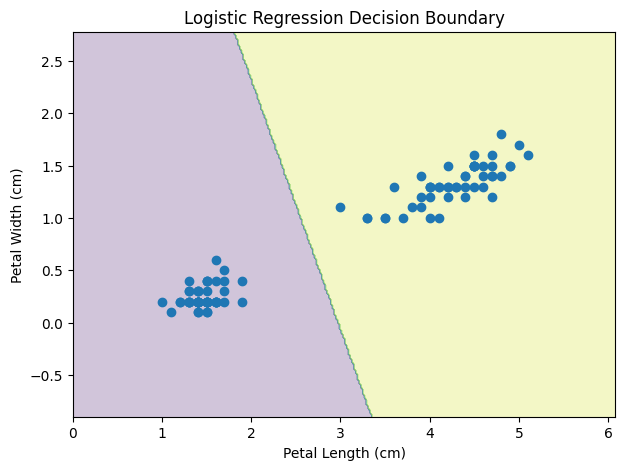

In [9]:
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = logr.predict(np.c_[xx.ravel(), yy.ravel()])
label_map = {name:i for i, name in enumerate(sorted(set(Z)))}
Z_int = np.vectorize(label_map.get)(Z).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z_int, alpha=0.25)
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Logistic Regression Decision Boundary')
plt.show()

## Q10: Predict for New Sample

In [10]:
sample = [[4.8, 1.6]]
prediction = logr.predict(sample)
print('Predicted class for sample:', prediction[0])

Predicted class for sample: versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---
### ✔ End of Assignment-8

### Conclusion

Based on the accuracy score and the decision boundary visualization, the Logistic Regression model performs very well in classifying the 'setosa' and 'versicolor' iris species using 'petal length (cm)' and 'petal width (cm)'.

*   **Accuracy:** The high accuracy score (from Q8) indicates that the model correctly predicted a large majority of the test samples.
*   **Decision Boundary:** The visualization (from Q9) clearly shows a linear separation between the two classes, and the decision boundary effectively divides the data points. This aligns with the good performance observed, as 'setosa' and 'versicolor' are generally linearly separable based on these features.

In summary, for this specific binary classification problem with these two features, Logistic Regression proved to be an effective and interpretable model.